In [25]:
from keras.datasets import mnist
from keras.utils import to_categorical
from keras import layers,models,regularizers
import numpy as np
import matplotlib.pyplot as plt

In [26]:
(train_x,train_y),(test_x,test_y) = mnist.load_data()

In [27]:
print("train_x.shape : ",train_x.shape)
print("test_x.shape : ",test_x.shape)

train_x.shape :  (60000, 28, 28)
test_x.shape :  (10000, 28, 28)


In [28]:
train_x = train_x.reshape((train_x.shape[0],28*28)).astype('float32') / 255
test_x = test_x.reshape((10000,28*28)).astype('float32') / 255

# train_x = train_x.astype('float32') / 255
# test_x = test_x.astype('float32') / 255

train_y = to_categorical(train_y)
test_y = to_categorical(test_y)

In [29]:
validation_x = train_x[50000:60000]
validation_y = train_y[50000:60000]

train_x = train_x[:50000]
train_y = train_y[:50000]

print("train_x.shape : ",train_x.shape)
print("validation_x.shape : ",validation_x.shape)
print("test_x.shape : ",test_x.shape)

train_x.shape :  (50000, 784)
validation_x.shape :  (10000, 784)
test_x.shape :  (10000, 784)


In [30]:
def buildModel(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dense(neuronNum , activation='relu') ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [48]:
def buildModelRegulalize(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , kernel_regularizer=regularizers.l2(0.001) , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dense(neuronNum , kernel_regularizer=regularizers.l2(0.001) , activation='relu') ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [32]:
def buildModelDropout(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dropout(0.5) ,
        layers.Dense(neuronNum , activation='relu') ,
        layers.Dropout(0.5) ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [33]:
history_smaller = buildModel(32, train_x).fit(train_x, train_y, epochs=50, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/50


/Users/ponlawatchangto/Desktop/VsCode/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - accuracy: 0.8169 - loss: 0.6648 - val_accuracy: 0.9111 - val_loss: 0.3070
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 621us/step - accuracy: 0.9174 - loss: 0.2868 - val_accuracy: 0.9269 - val_loss: 0.2473
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step - accuracy: 0.9337 - loss: 0.2311 - val_accuracy: 0.9430 - val_loss: 0.2025
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - accuracy: 0.9440 - loss: 0.1951 - val_accuracy: 0.9441 - val_loss: 0.1919
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step - accuracy: 0.9499 - loss: 0.1713 - val_accuracy: 0.9475 - val_loss: 0.1856
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step - accuracy: 0.9560 - loss: 0.1522 - val_accuracy: 0.9529 - val_loss: 0.1636
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step - accuracy: 0.9598 - loss: 0.1382 - val_accuracy: 0.9564 - val_loss: 0.1495
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 651us/step - accuracy: 0.9629 - loss: 0.1266 - val_accurac

In [34]:
history_original = buildModel(64, train_x).fit(train_x, train_y, epochs=50, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8601 - loss: 0.5150 - val_accuracy: 0.9255 - val_loss: 0.2601
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - accuracy: 0.9334 - loss: 0.2332 - val_accuracy: 0.9461 - val_loss: 0.1923
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 759us/step - accuracy: 0.9487 - loss: 0.1754 - val_accuracy: 0.9585 - val_loss: 0.1496
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 763us/step - accuracy: 0.9577 - loss: 0.1411 - val_accuracy: 0.9624 - val_loss: 0.1327
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 770us/step - accuracy: 0.9652 - loss: 0.1180 - val_accuracy: 0.9646 - val_loss: 0.1222
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 769us/step - accuracy: 0.9701 - loss: 0.1012 - val_accuracy: 0.9671 - val_loss: 0.1122
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - accuracy: 0.9730 - loss: 0.0884 - val_accuracy: 0.9687 - val_loss: 0.1095
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 761us/step - accuracy: 0.9773 - loss: 0.0769 - va

In [35]:
history_larger = buildModel(512, train_x).fit(train_x, train_y, epochs=50, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9005 - loss: 0.3219 - val_accuracy: 0.9592 - val_loss: 0.1429
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9654 - loss: 0.1124 - val_accuracy: 0.9671 - val_loss: 0.1173
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9777 - loss: 0.0721 - val_accuracy: 0.9729 - val_loss: 0.0902
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9851 - loss: 0.0487 - val_accuracy: 0.9679 - val_loss: 0.1043
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9888 - loss: 0.0356 - val_accuracy: 0.9759 - val_loss: 0.0821
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9920 - loss: 0.0257 - val_accuracy: 0.9803 - val_loss: 0.0728
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9944 - loss: 0.0177 - val_accuracy: 0.9770 - val_loss: 0.0842
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9957 - loss: 0.0136 - val_accuracy: 0.

In [36]:
def plotLoss(history,name) :
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.plot(epochs,loss,'r',label='Training loss')
    plt.plot(epochs,val_loss,'b',label='Validation loss')
    plt.title('Training and Validation Loss '+ name)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [37]:
def plotAcc(history,name) :
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1 , len(accuracy) + 1)
    plt.plot(epochs,accuracy,'r',label='Training Accuracy')
    plt.plot(epochs,val_accuracy,'b',label='Validation Accuracy')
    plt.title('Training and Validation Accuracy ' + name)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

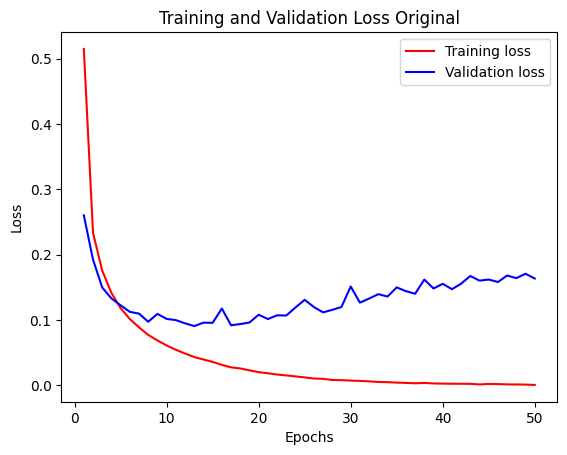

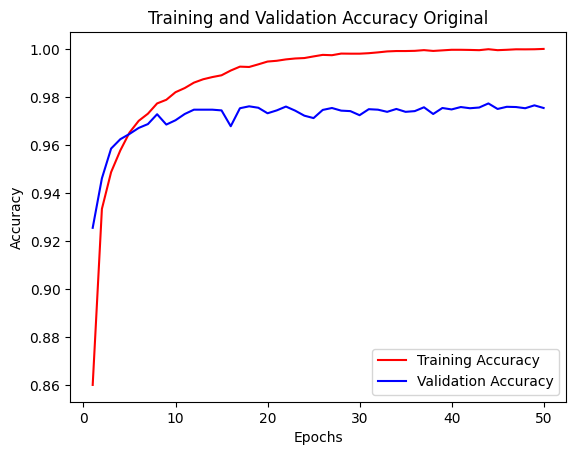

In [38]:
plotLoss(history_original,"Original")
plotAcc(history_original,"Original")

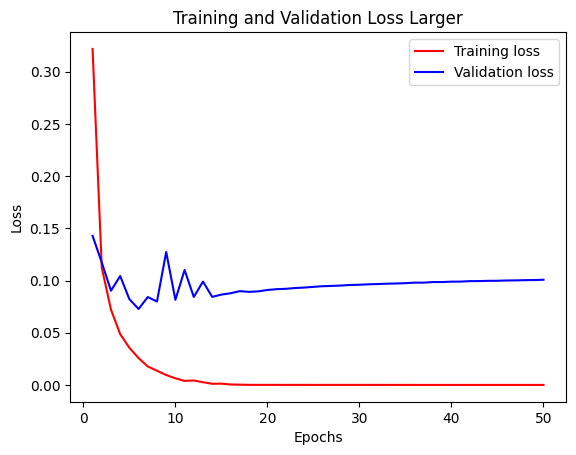

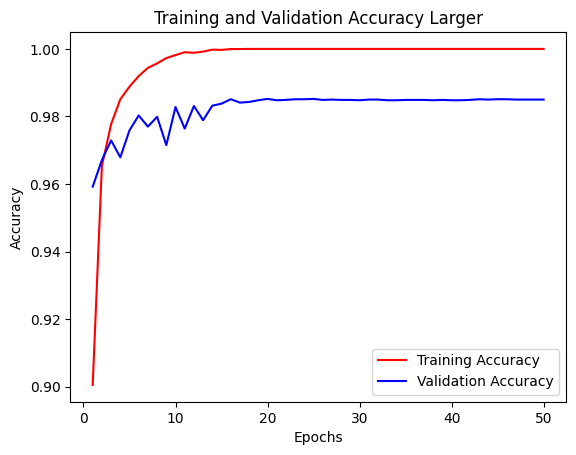

In [39]:
plotLoss(history_larger,"Larger")
plotAcc(history_larger,"Larger")

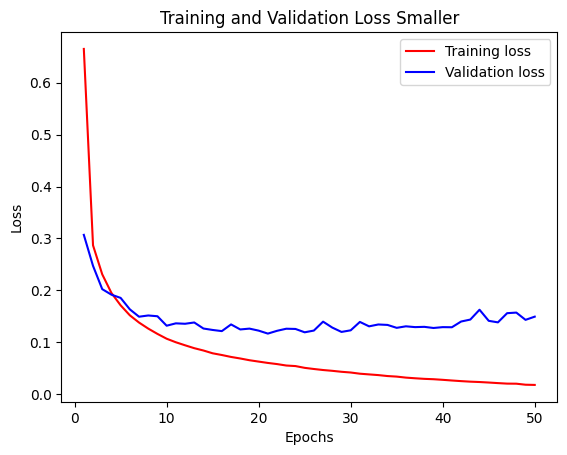

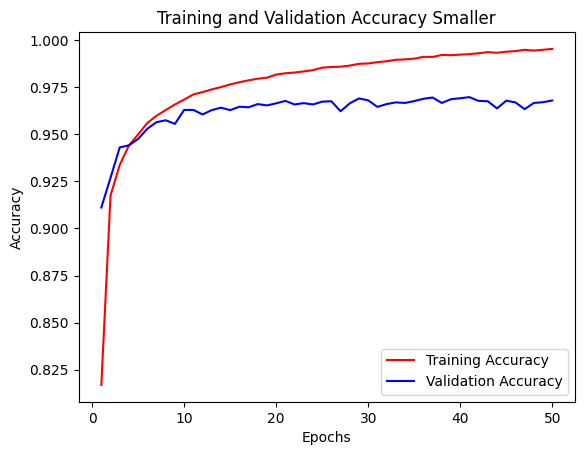

In [40]:
plotLoss(history_smaller,"Smaller")
plotAcc(history_smaller,"Smaller")

In [41]:
history_Dropout = buildModelDropout(64 , train_x).fit(train_x,train_y,epochs=50,batch_size=256,validation_data=(validation_x,validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6258 - loss: 1.1250 - val_accuracy: 0.9070 - val_loss: 0.3459
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - accuracy: 0.8237 - loss: 0.5845 - val_accuracy: 0.9305 - val_loss: 0.2491
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - accuracy: 0.8594 - loss: 0.4806 - val_accuracy: 0.9395 - val_loss: 0.2186
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 898us/step - accuracy: 0.8752 - loss: 0.4257 - val_accuracy: 0.9436 - val_loss: 0.1998
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - accuracy: 0.8837 - loss: 0.3984 - val_accuracy: 0.9498 - val_loss: 0.1864
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 918us/step - accuracy: 0.8927 - loss: 0.3734 - val_accuracy: 0.9492 - val_loss: 0.1798
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.8991 - loss: 0.3531 - val_accuracy: 0.9547 - val_loss: 0.1665
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - accuracy: 0.9019 - loss: 0.3432 - va

In [42]:
history_Regularized = buildModelRegulalize(64 , train_x).fit(train_x,train_y,epochs=50,batch_size=256,validation_data=(validation_x,validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8621 - loss: 0.6666 - val_accuracy: 0.9259 - val_loss: 0.4057
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step - accuracy: 0.9292 - loss: 0.3785 - val_accuracy: 0.9343 - val_loss: 0.3532
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step - accuracy: 0.9419 - loss: 0.3199 - val_accuracy: 0.9517 - val_loss: 0.2993
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - accuracy: 0.9516 - loss: 0.2832 - val_accuracy: 0.9561 - val_loss: 0.2752
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step - accuracy: 0.9566 - loss: 0.2585 - val_accuracy: 0.9535 - val_loss: 0.2691
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - accuracy: 0.9611 - loss: 0.2393 - val_accuracy: 0.9525 - val_loss: 0.2601
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - accuracy: 0.9646 - loss: 0.2224 - val_accuracy: 0.9583 - val_loss: 0.2439
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 782us/step - accuracy: 0.9666 - loss: 0.2120 - va

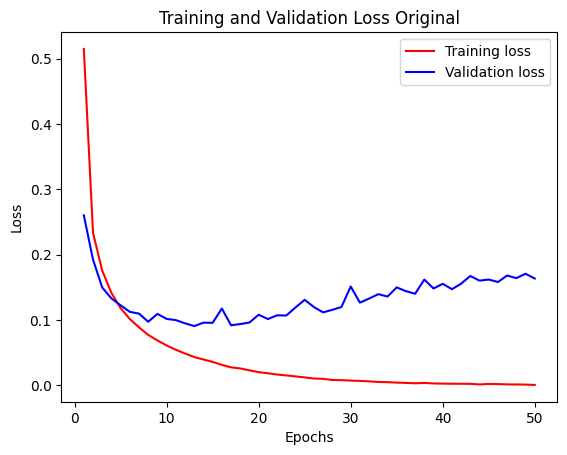

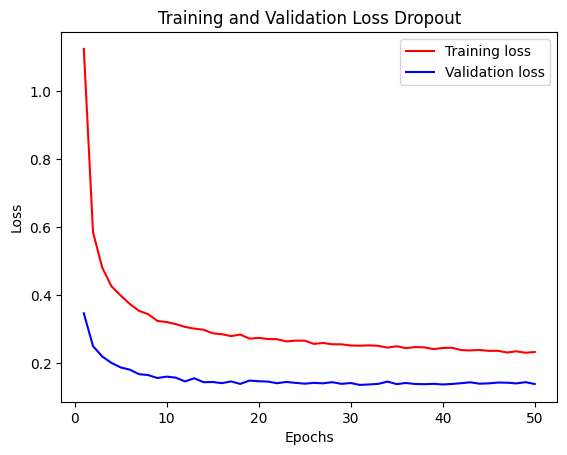

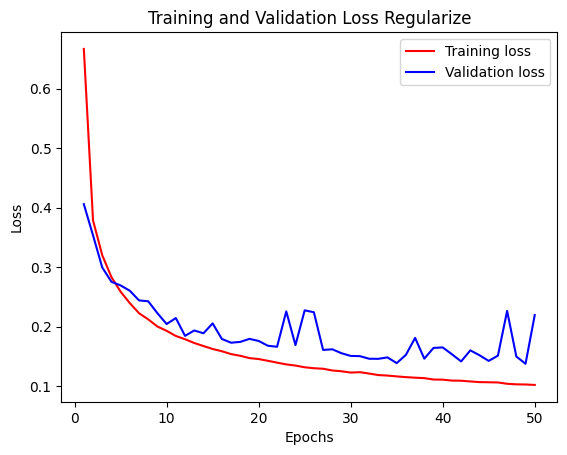

In [43]:
plotLoss(history_original,'Original')
plotLoss(history_Dropout,'Dropout')
plotLoss(history_Regularized,'Regularize')

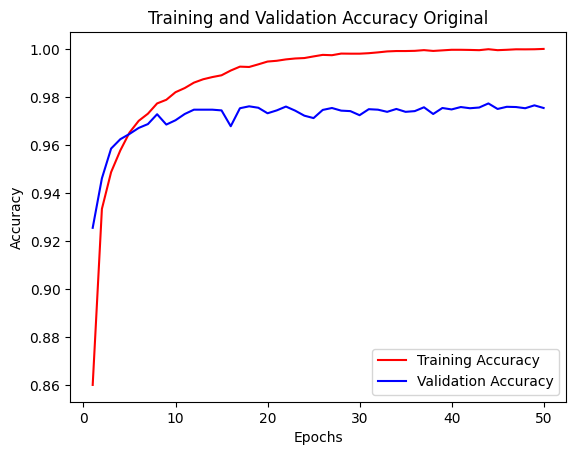

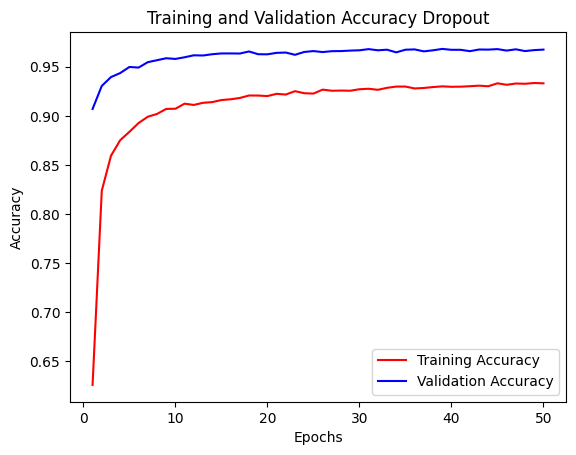

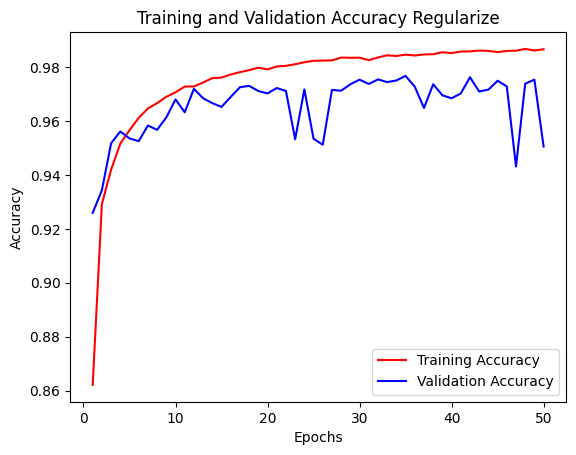

In [44]:
plotAcc(history_original,'Original')
plotAcc(history_Dropout,'Dropout')
plotAcc(history_Regularized,'Regularize')

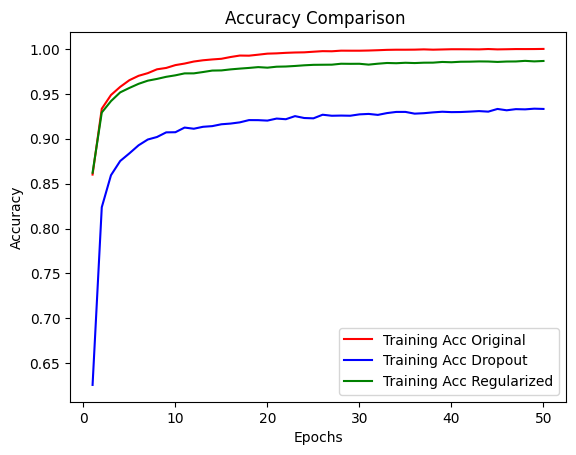

In [45]:
acc_ori = history_original.history['accuracy']
acc_DropOut = history_Dropout.history['accuracy']
acc_Regularized = history_Regularized.history['accuracy']
epochs = range(1,len(acc_ori)+1)
plt.plot(epochs,acc_ori,'r',label='Training Acc Original')
plt.plot(epochs,acc_DropOut,'b',label='Training Acc Dropout')
plt.plot(epochs,acc_Regularized,'g',label='Training Acc Regularized')
plt.title('Accuracy Comparison ')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

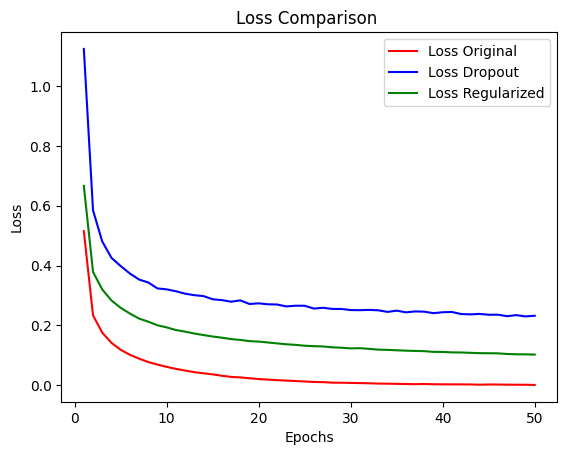

In [46]:
loss_ori = history_original.history['loss']
loss_DropOut = history_Dropout.history['loss']
loss_Regularized = history_Regularized.history['loss']
epochs = range(1,len(loss_ori)+1)
plt.plot(epochs,loss_ori,'r',label='Loss Original')
plt.plot(epochs,loss_DropOut,'b',label='Loss Dropout')
plt.plot(epochs,loss_Regularized,'g',label='Loss Regularized')
plt.title('Loss Comparison ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

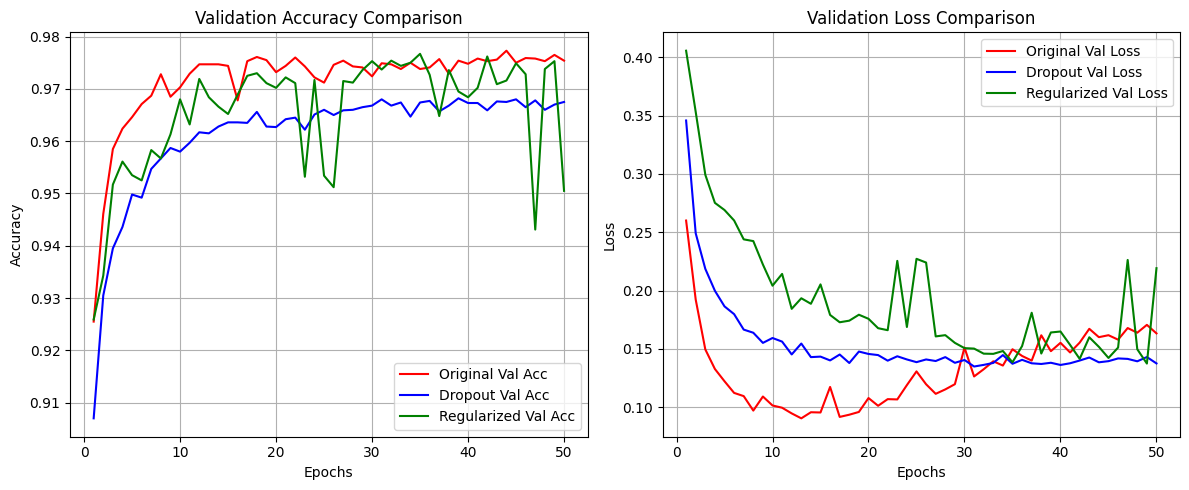

In [ ]:
val_acc_ori = history_original.history['val_accuracy']
val_acc_drop = history_Dropout.history['val_accuracy']
val_acc_reg = history_Regularized.history['val_accuracy']

val_loss_ori = history_original.history['val_loss']
val_loss_drop = history_Dropout.history['val_loss']
val_loss_reg = history_Regularized.history['val_loss']

epochs = range(1, len(val_acc_ori) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, val_acc_ori, 'r', label='Original Val Acc')
plt.plot(epochs, val_acc_drop, 'b', label='Dropout Val Acc')
plt.plot(epochs, val_acc_reg, 'g', label='Regularized Val Acc')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, val_loss_ori, 'r', label='Original Val Loss')
plt.plot(epochs, val_loss_drop, 'b', label='Dropout Val Loss')
plt.plot(epochs, val_loss_reg, 'g', label='Regularized Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [54]:
loss_ori , acc_ori = history_original.model.evaluate(test_x,test_y)
print(f"Loss : {loss_ori} , Acc : {acc_ori}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 315us/step - accuracy: 0.9781 - loss: 0.1344
Loss : 0.13435569405555725 , Acc : 0.9781000018119812


In [55]:
loss_Large , acc_Large = history_larger.model.evaluate(test_x,test_y)
print(f"Loss : {loss_Large} , Acc : {acc_Large}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - accuracy: 0.9831 - loss: 0.0921
Loss : 0.0920991599559784 , Acc : 0.9830999970436096


In [56]:
loss_small , acc_small = history_smaller.model.evaluate(test_x,test_y)
print(f"Loss : {loss_small} , Acc : {acc_small}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/step - accuracy: 0.9681 - loss: 0.1346
Loss : 0.13463518023490906 , Acc : 0.9681000113487244


In [57]:
loss_dropout , acc_dropout = history_Dropout.model.evaluate(test_x,test_y)
print(f"Loss : {loss_dropout} , Acc : {acc_dropout}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 290us/step - accuracy: 0.9638 - loss: 0.1512
Loss : 0.151175394654274 , Acc : 0.9638000130653381


In [58]:
loss_Regularized , acc_Regularized = history_Regularized.model.evaluate(test_x,test_y)
print(f"Loss : {loss_Regularized} , Acc : {acc_Regularized}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 316us/step - accuracy: 0.9432 - loss: 0.2352
Loss : 0.23522987961769104 , Acc : 0.9431999921798706
